In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
#download all libraries
!apt-get install -y tesseract-ocr tesseract-ocr-ind
!pip install pytesseract opencv-python
!pip install ultralytics
!pip install sacremoses

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
tesseract-ocr-ind is already the newest version (1:4.00~git30-7274cfa-1.1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.


##### FINAL PIPELINE

In [8]:
import os
import cv2
import json
import pytesseract
from ultralytics import YOLO
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Paths
trained_model_path = "/content/drive/MyDrive/NLP_pro/yolo_training/manhwa_yolo_training_res2/weights/best.pt"
test_images_dir = "/content/drive/MyDrive/NLP_pro/manhwa_test_2"
output_images_dir = "/content/drive/MyDrive/NLP_pro/manhwa_test_results/predictions"
output_crops_dir = "/content/drive/MyDrive/NLP_pro/manhwa_test_results/speech_bubble_crops"
bbox_output_dir = "/content/drive/MyDrive/NLP_pro/manhwa_test_results/test_bbox"
ocr_results_dir = "/content/drive/MyDrive/NLP_pro/manhwa_test_results/speech_bubble_ocr_results"
translations_dir = "/content/drive/MyDrive/NLP_pro/manhwa_test_results/speech_bubble_translations"
translated_images_dir = "/content/drive/MyDrive/NLP_pro/manhwa_test_results/translated_images"

# Ensure directories exist
os.makedirs(output_images_dir, exist_ok=True)
os.makedirs(output_crops_dir, exist_ok=True)
os.makedirs(bbox_output_dir, exist_ok=True)
os.makedirs(ocr_results_dir, exist_ok=True)
os.makedirs(translations_dir, exist_ok=True)
os.makedirs(translated_images_dir, exist_ok=True)

# Initialize YOLO and Translation Models
yolo_model = YOLO(trained_model_path)
translation_model_path = "/content/drive/MyDrive/NLP_pro/final_trans_model"

# Load the tokenizer and translation model
try:
    tokenizer = AutoTokenizer.from_pretrained(translation_model_path)
    translation_model = AutoModelForSeq2SeqLM.from_pretrained(translation_model_path)
    print("Tokenizer and translation model loaded successfully!")
except Exception as e:
    print(f"Error loading translation model or tokenizer: {e}")
    raise

# Tesseract OCR configuration
pytesseract.pytesseract.tesseract_cmd = r'/usr/bin/tesseract'
ocr_lang = 'ind'
custom_config = r'--oem 3 --psm 6'


def extract_bounding_boxes_and_crops():
    """Run YOLO to detect bounding boxes and save cropped speech bubbles."""
    test_images = [
        os.path.join(test_images_dir, f)
        for f in os.listdir(test_images_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    for img_path in test_images:
        results = yolo_model.predict(source=img_path, save=True, project=output_images_dir, name="predict", exist_ok=True)

        bounding_boxes = []
        img = cv2.imread(img_path)
        if img is None:
            print(f"Failed to load image: {img_path}")
            continue

        for i, box in enumerate(results[0].boxes.xyxy):
            x_min, y_min, x_max, y_max = map(int, box[:4])
            bounding_boxes.append({"x_min": x_min, "y_min": y_min, "x_max": x_max, "y_max": y_max})

            crop = img[y_min:y_max, x_min:x_max]
            crop_filepath = os.path.join(output_crops_dir, f"{os.path.basename(img_path).split('.')[0]}_bubble_{i}.jpg")
            cv2.imwrite(crop_filepath, crop)

        bbox_filepath = os.path.join(bbox_output_dir, f"{os.path.basename(img_path).split('.')[0]}_bbox.json")
        with open(bbox_filepath, "w") as bbox_file:
            json.dump(bounding_boxes, bbox_file, indent=4)
        print(f"Processed {img_path}: {len(bounding_boxes)} bounding boxes saved.")


def perform_ocr_on_crops():
    """Perform OCR on speech bubble crops and save results."""
    cropped_images = [
        os.path.join(output_crops_dir, f)
        for f in os.listdir(output_crops_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    for crop_path in cropped_images:
        img_name = os.path.basename(crop_path).split('_bubble_')[0]
        bubble_index = crop_path.split('_bubble_')[-1].split('.')[0]
        ocr_text = ""

        crop = cv2.imread(crop_path)
        if crop is not None:
            gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
            ocr_text = pytesseract.image_to_string(gray, lang=ocr_lang, config=custom_config).strip()

        ocr_filepath = os.path.join(ocr_results_dir, f"{img_name}_ocr.json")
        if not os.path.exists(ocr_filepath):
            with open(ocr_filepath, "w") as ocr_file:
                json.dump({}, ocr_file)

        with open(ocr_filepath, "r+") as ocr_file:
            ocr_data = json.load(ocr_file)
            ocr_data[str(bubble_index)] = ocr_text
            ocr_file.seek(0)
            json.dump(ocr_data, ocr_file, indent=4)
        print(f"OCR result saved for {crop_path}: {ocr_text}")


def translate_ocr_results():
    """Translate OCR text and save translations."""
    ocr_files = [
        os.path.join(ocr_results_dir, f)
        for f in os.listdir(ocr_results_dir)
        if f.endswith(".json")
    ]

    for ocr_file in ocr_files:
        with open(ocr_file, "r") as file:
            ocr_data = json.load(file)

        translations = {}
        for bubble_index, ocr_text in ocr_data.items():
            if ocr_text.strip():
                inputs = tokenizer(ocr_text, return_tensors="pt", max_length=512, truncation=True)
                outputs = translation_model.generate(**inputs, max_length=512)
                translated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
                translations[bubble_index] = translated_text
            else:
                translations[bubble_index] = "No text detected"

        translation_filepath = os.path.join(translations_dir, f"{os.path.basename(ocr_file).replace('_ocr.json', '_translations.json')}")
        with open(translation_filepath, "w") as file:
            json.dump(translations, file, indent=4)
        print(f"Translations saved for {ocr_file}.")


from PIL import Image, ImageDraw, ImageFont
import cv2
import numpy as np

from PIL import Image, ImageDraw, ImageFont
import cv2
import numpy as np

def overlay_translations():
    """Overlay translations onto original images using a custom TTF font."""
    bbox_files = [
        os.path.join(bbox_output_dir, f)
        for f in os.listdir(bbox_output_dir)
        if f.endswith(".json")
    ]

    # Path to the custom font
    font_path = "/content/drive/MyDrive/NLP_pro/animeace2bb_tt/animeace2_reg.ttf"

    print("Overlaying translations...")
    for bbox_file in bbox_files:
        image_name = os.path.basename(bbox_file).replace("_bbox.json", "")
        img_path = os.path.join(test_images_dir, f"{image_name}.png")
        if not os.path.exists(img_path):
            img_path = os.path.join(test_images_dir, f"{image_name}.jpg")

        if not os.path.exists(img_path):
            print(f"Image file not found for {image_name}.")
            continue

        # Load the image
        img = cv2.imread(img_path)
        if img is None:
            print(f"Failed to load image: {img_path}")
            continue

        # Convert the image to a Pillow Image
        img_pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        draw = ImageDraw.Draw(img_pil)

        # Load bounding boxes
        with open(bbox_file, "r") as file:
            bounding_boxes = json.load(file)

        # Load translations
        translation_filepath = os.path.join(translations_dir, f"{image_name}_translations.json")
        if not os.path.exists(translation_filepath):
            print(f"Translation file not found for {image_name}.")
            continue

        with open(translation_filepath, "r") as file:
            translations = json.load(file)

        # Overlay translations
        for box, bubble_index in zip(bounding_boxes, translations.keys()):
            x_min, y_min, x_max, y_max = box["x_min"], box["y_min"], box["x_max"], box["y_max"]
            translation = translations[bubble_index]

            # Draw a white rectangle to "erase" the original text
            draw.rectangle([(x_min, y_min), (x_max, y_max)], fill="white")

            # Load the custom font
            try:
                font_size = 20  # Initial font size
                font = ImageFont.truetype(font_path, font_size)
            except Exception as e:
                print(f"Error loading font: {e}")
                return

            # Split translation into wrapped lines
            box_width = x_max - x_min
            box_height = y_max - y_min
            max_line_width = box_width - 10  # Padding for text inside the box

            words = translation.split(" ")
            wrapped_lines = []
            current_line = ""
            for word in words:
                test_line = f"{current_line} {word}".strip()
                # Use `getbbox()` to calculate text size
                text_width = font.getbbox(test_line)[2]
                if text_width > max_line_width:
                    wrapped_lines.append(current_line)
                    current_line = word
                else:
                    current_line = test_line
            if current_line:
                wrapped_lines.append(current_line)

            # Dynamically adjust font size if text height exceeds the bounding box
            line_height = font.getbbox("Test")[3] + 5
            total_text_height = len(wrapped_lines) * line_height
            while total_text_height > box_height and font_size > 5:
                font_size -= 1
                font = ImageFont.truetype(font_path, font_size)
                line_height = font.getbbox("Test")[3] + 5
                total_text_height = len(wrapped_lines) * line_height

            # Calculate starting y-coordinate to center the text vertically
            start_y = y_min + (box_height - total_text_height) // 2

            # Draw each line of text
            for i, line in enumerate(wrapped_lines):
                text_width = font.getbbox(line)[2]
                text_x = x_min + (box_width - text_width) // 2  # Center horizontally
                text_y = start_y + i * line_height
                draw.text((text_x, text_y), line, font=font, fill="black")

        # Convert the Pillow Image back to OpenCV format
        img = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

        # Save the resulting image
        output_path = os.path.join(translated_images_dir, f"{image_name}_translated.png")
        cv2.imwrite(output_path, img)
        print(f"Translated image saved: {output_path}")




# Execute pipeline
extract_bounding_boxes_and_crops()
perform_ocr_on_crops()
translate_ocr_results()
overlay_translations()


Tokenizer and translation model loaded successfully!

image 1/1 /content/drive/MyDrive/NLP_pro/manhwa_test_2/mt_1.png: 544x640 3 Textss, 5660.5ms
Speed: 6.3ms preprocess, 5660.5ms inference, 1.8ms postprocess per image at shape (1, 3, 544, 640)
Results saved to /content/drive/MyDrive/NLP_pro/manhwa_test_results/predictions/predict
Processed /content/drive/MyDrive/NLP_pro/manhwa_test_2/mt_1.png: 3 bounding boxes saved.

image 1/1 /content/drive/MyDrive/NLP_pro/manhwa_test_2/mt_2.png: 608x640 2 Textss, 4154.0ms
Speed: 4.2ms preprocess, 4154.0ms inference, 1.0ms postprocess per image at shape (1, 3, 608, 640)
Results saved to /content/drive/MyDrive/NLP_pro/manhwa_test_results/predictions/predict
Processed /content/drive/MyDrive/NLP_pro/manhwa_test_2/mt_2.png: 2 bounding boxes saved.

image 1/1 /content/drive/MyDrive/NLP_pro/manhwa_test_2/mt_3.png: 640x576 3 Textss, 6154.7ms
Speed: 4.0ms preprocess, 6154.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 576)
Results saved to 

Displaying the pipeline for: /content/drive/MyDrive/NLP_pro/manhwa_test_2/mt_12.png


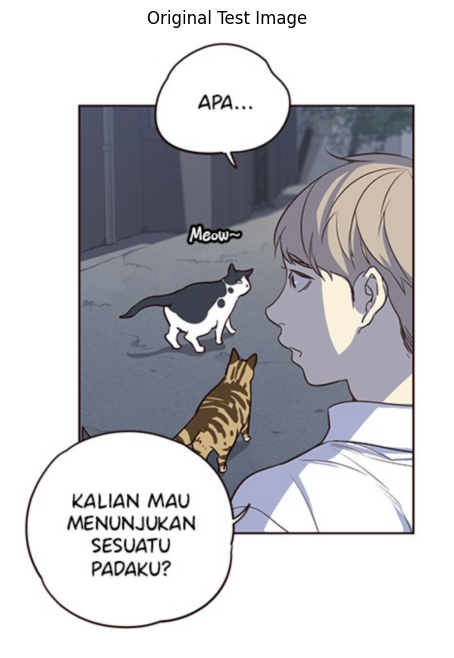

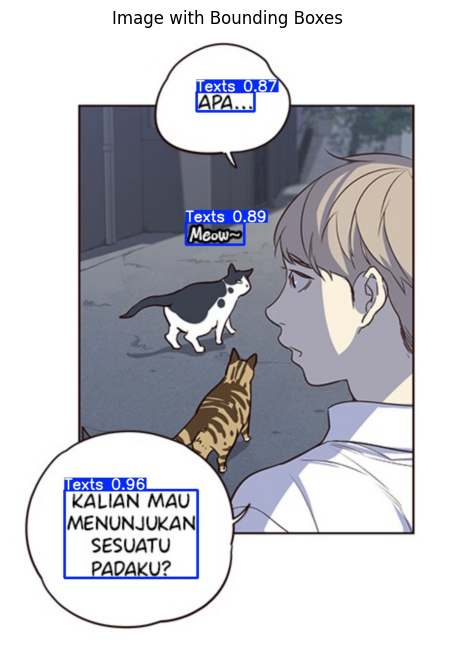

Cropped Speech Bubbles:


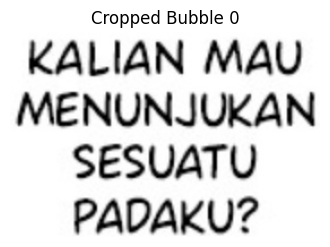

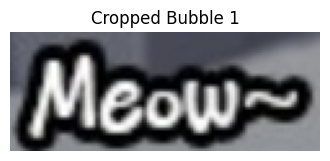

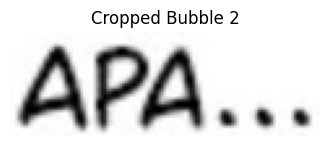


OCR Text:
Bubble 0: KALIAN MAU
MENUNJUKAN
SESUATU
PADAKU?
Bubble 1: NE
Bubble 2: APA...

Translations:
Bubble 0: Would you like to offer something to me?
Bubble 1: NE
Bubble 2: What...

Translated Image:


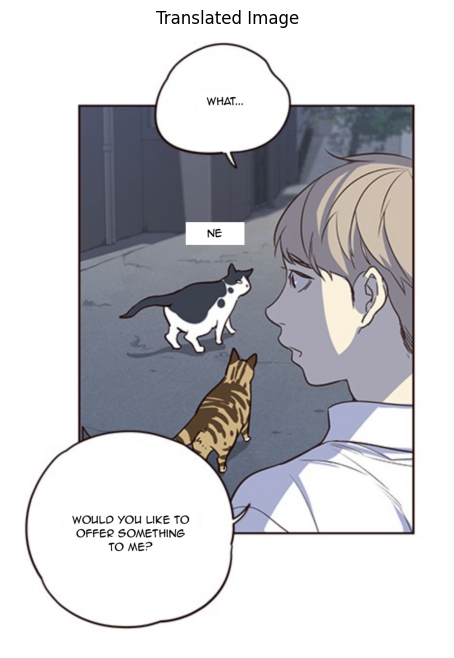

In [9]:
import os
import cv2
import json
import matplotlib.pyplot as plt

# Paths
test_images_dir = "/content/drive/MyDrive/NLP_pro/manhwa_test_2"
output_images_dir = "/content/drive/MyDrive/NLP_pro/manhwa_test_results/predictions"
output_crops_dir = "/content/drive/MyDrive/NLP_pro/manhwa_test_results/speech_bubble_crops"
bbox_output_dir = "/content/drive/MyDrive/NLP_pro/manhwa_test_results/test_bbox"
ocr_results_dir = "/content/drive/MyDrive/NLP_pro/manhwa_test_results/speech_bubble_ocr_results"
translations_dir = "/content/drive/MyDrive/NLP_pro/manhwa_test_results/speech_bubble_translations"
translated_images_dir = "/content/drive/MyDrive/NLP_pro/manhwa_test_results/translated_images"

def display_pipeline_for_image(test_image_path):
    """Display the pipeline for a manually specified test image."""
    if not os.path.exists(test_image_path):
        print(f"Test image not found: {test_image_path}")
        return

    image_name = os.path.basename(test_image_path).split('.')[0]

    # Paths to corresponding files
    bbox_filepath = os.path.join(bbox_output_dir, f"{image_name}_bbox.json")
    ocr_filepath = os.path.join(ocr_results_dir, f"{image_name}_ocr.json")
    translation_filepath = os.path.join(translations_dir, f"{image_name}_translations.json")
    translated_image_path = os.path.join(translated_images_dir, f"{image_name}_translated.png")

    # Display the original test image
    print(f"Displaying the pipeline for: {test_image_path}")
    img = cv2.imread(test_image_path)
    if img is not None:
        plt.figure(figsize=(8, 8))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.title("Original Test Image")
        plt.show()

    # Display the image with bounding boxes
    prediction_image_path = os.path.join(output_images_dir, "predict", f"{image_name}.jpg")
    if os.path.exists(prediction_image_path):
        pred_img = cv2.imread(prediction_image_path)
        if pred_img is not None:
            plt.figure(figsize=(8, 8))
            plt.imshow(cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB))
            plt.axis("off")
            plt.title("Image with Bounding Boxes")
            plt.show()

    # Load and display cropped speech bubbles
    print("Cropped Speech Bubbles:")
    if os.path.exists(bbox_filepath):
        with open(bbox_filepath, "r") as file:
            bounding_boxes = json.load(file)

        for idx, box in enumerate(bounding_boxes):
            crop_path = os.path.join(output_crops_dir, f"{image_name}_bubble_{idx}.jpg")
            if os.path.exists(crop_path):
                crop_img = cv2.imread(crop_path)
                if crop_img is not None:
                    plt.figure(figsize=(4, 4))
                    plt.imshow(cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB))
                    plt.axis("off")
                    plt.title(f"Cropped Bubble {idx}")
                    plt.show()

    # Display OCR text
    print("\nOCR Text:")
    if os.path.exists(ocr_filepath):
        with open(ocr_filepath, "r") as file:
            ocr_data = json.load(file)
        for bubble_idx, ocr_text in ocr_data.items():
            print(f"Bubble {bubble_idx}: {ocr_text}")

    # Display translations
    print("\nTranslations:")
    if os.path.exists(translation_filepath):
        with open(translation_filepath, "r") as file:
            translations = json.load(file)
        for bubble_idx, translated_text in translations.items():
            print(f"Bubble {bubble_idx}: {translated_text}")

    # Display the translated image
    print("\nTranslated Image:")
    if os.path.exists(translated_image_path):
        translated_img = cv2.imread(translated_image_path)
        if translated_img is not None:
            plt.figure(figsize=(8, 8))
            plt.imshow(cv2.cvtColor(translated_img, cv2.COLOR_BGR2RGB))
            plt.axis("off")
            plt.title("Translated Image")
            plt.show()

# Specify the path to the test image manually
test_image_path = "/content/drive/MyDrive/NLP_pro/manhwa_test_2/mt_12.png"
display_pipeline_for_image(test_image_path)
